In [1]:
import pandas as pd
from torch.nn import MSELoss

pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import torch
from torch import nn
import torch.optim
from torchinfo import summary


import config

from model_utils import train_test_split, FPLDataPipe, Trainer, set_seed
from data_utils import sort_data, colors_config



In [2]:
set_seed(77)

In [3]:
data = pd.read_parquet(config.FPL_DATA_PATH)

In [4]:
data.isna().sum().sum()

np.int64(0)

In [5]:
data = sort_data(data)
data.head()

,transfers_balance,position,gw,value,transfers_out,transfers_trend,code,kickoff_time,element,season,was_home,selected,name,transfers_in,opponent_team,total_points,bonus_ema_8,bps_ema_8,ict_index_ema_8,value_ema_8,threat_ema_8,transfers_balance_ema_8,transfers_in_ema_8,transfers_out_ema_8,transfers_trend_ema_8,xp_ema_8,assists_ema_8,clean_sheets_ema_8,creativity_ema_8,xa_ema_8,xg_involvements_ema_8,xg_conceded_ema_8,goals_conceded_ema_8,goals_scored_ema_8,minutes_ema_8,own_goals_ema_8,penalties_missed_ema_8,penalties_saved_ema_8,red_cards_ema_8,saves_ema_8,yellow_cards_ema_8,team_score_ema_8,opp_score_ema_8,score_diff_ema_8,xg_chain_ema_8,xg_buildup_ema_8,team_points_ema_8,opp_points_ema_8,team_xp_ema_8,opp_xp_ema_8,team_xg_ema_8,opp_xg_ema_8,team_np_xg_difference_ema_8,team_ppda_ema_8,opp_ppda_ema_8,team_deep_completions_ema_8,opp_deep_completions_ema_8,ppda_diff_ema_8,xa_per_90_ema_8,xg_involvements_per_90_ema_8,xg_per_90_ema_8,xg_conceded_per_90_ema_8,ict_index_per_90_ema_8,xg_chain_per_90_ema_8,xg_buildup_per_90_ema_8,team_xg_per_90_ema_8,opp_xg_per_90_ema_8,team_np_xg_difference_per_90_ema_8,bonus_lagged_1,bps_lagged_1,ict_index_lagged_1,influence_lagged_1,threat_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,transfers_trend_lagged_1,xp_lagged_1,assists_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,xa_lagged_1,xg_involvements_lagged_1,xg_lagged_1,xg_conceded_lagged_1,goals_conceded_lagged_1,goals_scored_lagged_1,minutes_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,yellow_cards_lagged_1,team_score_lagged_1,opp_score_lagged_1,score_diff_lagged_1,shots_lagged_1,xg_chain_lagged_1,xg_buildup_lagged_1,team_points_lagged_1,opp_points_lagged_1,team_xp_lagged_1,opp_xp_lagged_1,team_xg_lagged_1,opp_xg_lagged_1,team_np_xg_difference_lagged_1,team_ppda_lagged_1,opp_ppda_lagged_1,team_deep_completions_lagged_1,opp_deep_completions_lagged_1,ppda_diff_lagged_1,xa_per_90_lagged_1,xg_involvements_per_90_lagged_1,xg_per_90_lagged_1,xg_conceded_per_90_lagged_1,ict_index_per_90_lagged_1,xg_chain_per_90_lagged_1,xg_buildup_per_90_lagged_1,team_xg_per_90_lagged_1,opp_xg_per_90_lagged_1,team_np_xg_difference_per_90_lagged_1,xg_share_lagged_1
0,0.0,GK,32.0,4.0,0.0,0.000000,11948.0,2023-04-22T14:00:00Z,760.0,2223.0,False,0.0,Andy Lonergan,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17.0,GK,33.0,4.0,1.0,0.515152,11948.0,2023-04-27T18:45:00Z,760.0,2223.0,True,33.0,Andy Lonergan,18.0,15.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000000,0.000000,0.000000,0.000000,1.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,1.000000,1.000000,1.307300,1.177100,0.433712,0.368137,0.065575,8.818182,9.437500,3.000000,5.000000,-0.619318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.433712,0.368137,0.065575,8.818182,9.437500,3.0,5.0,-0.619318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19.0,GK,34.0,4.0,6.0,0.226190,11948.0,2023-05-01T19:00:00Z,760.0,2223.0,False,84.0,Andy Lonergan,25.0,10.0,0.0,0.0,0.0,0.0,4.0,0.0,3.777778,4.000000,0.222222,0.114478,1.055556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.222222,0.888889,-0.666667,0.0,0.0,0.777778,1.444444,1.056344,1.522144,0.510000,0.922702,-0.412702,9.383838,9.340278,3.666667,5.8888

In [6]:
data.shape

(105856, 123)

In [7]:
cols_map = colors_config.FEATURES_GROUP

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [9]:
cols_map["static_cols"]

['position', 'was_home', 'starts']

In [10]:
cols_map["pre_game_cols"][:10]

['name',
 'position',
 'element',
 'was_home',
 'opponent_team',
 'was_home',
 'gw',
 'code',
 'season',
 'kickoff_time']

In [11]:
num_cols = [c for c in data.columns if "ema" in c or "lagg" in c] + [c for c in cols_map["pre_game_cols"] if c in data.columns and c not in ["name", "position", "element", "opponent_team", "gw", "code", "season", 'kickoff_time']]
len(num_cols)

115

In [12]:
cols_map["static_cols"]

['position', 'was_home', 'starts']

In [13]:
BATCH_SIZE = 256
fpl_data_pipe = FPLDataPipe(num_cols=[c for c in num_cols if c in data.columns],
                            cat_cols = [c for c in cols_map["static_cols"] if c in data.columns and c != "web_name" and c != "player_id" and c != "gw"],
                            batch_size=BATCH_SIZE)

In [14]:
data_splits = train_test_split(data)
fpl_data_pipe.prepare_data(**data_splits)

In [15]:
data_splits.get("X_train").shape

(56230, 122)

In [16]:
train_dataloader, valid_dataloader, test_dataloader = fpl_data_pipe.get_dataloaders()

In [17]:
x, y = next(iter(train_dataloader))
x.shape, y.shape

(torch.Size([256, 119]), torch.Size([256, 1]))

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):
        super(MLP, self).__init__()

        block1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.2)
        )
        block2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.1)
        )
        block3 = nn.Sequential(
            nn.Linear(hidden_size2, output_size)
        )

        self.block_stack = nn.Sequential(
            block1,
            block2,
            block3
        )

    def forward(self, x):
        return self.block_stack(x)

In [19]:
mlp = MLP(
    input_size=x.shape[1],
    hidden_size1=64,
    hidden_size2=16,
    output_size=1
).to(device)

In [20]:
summary(
    model=mlp,
    input_size=(BATCH_SIZE, x.shape[1]),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18

)

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
MLP                                      [256, 119]         [256, 1]           --                 True
├─Sequential: 1-1                        [256, 119]         [256, 1]           --                 True
│    └─Sequential: 2-1                   [256, 119]         [256, 64]          --                 True
│    │    └─Linear: 3-1                  [256, 119]         [256, 64]          7,680              True
│    │    └─LeakyReLU: 3-2               [256, 64]          [256, 64]          --                 --
│    │    └─BatchNorm1d: 3-3             [256, 64]          [256, 64]          128                True
│    │    └─Dropout: 3-4                 [256, 64]          [256, 64]          --                 --
│    └─Sequential: 2-2                   [256, 64]          [256, 16]          --                 True
│    │    └─Linear: 3-5                  [256, 64]          [256, 16]   

In [21]:
learning_rate = 0.001
weight_decay = .08
loss_fn = MSELoss(reduction="none")
optimizer = torch.optim.Adam(lr=learning_rate,
                            params=mlp.parameters(),
                            weight_decay=weight_decay)


In [22]:
trainer = Trainer(device=device,
                  random_state=77)

In [23]:
NUM_EPOCHS = 100
results, best_model = trainer.model_eval(train_dataloader=train_dataloader,
                             test_dataloader=valid_dataloader,
                             model=mlp,
                             num_epochs=NUM_EPOCHS,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             patience=NUM_EPOCHS//2)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 | LR: 0.001000 | Train Loss: 1.583 | Test Loss: 1.257
Train MSE: 5.467 | Test MSE: 4.677
Train MAE: 1.680 | Test MAE : 1.492
Train R2: -0.012 | Test R2: 0.124

Epoch: 10 | LR: 0.000500 | Train Loss: 1.166 | Test Loss: 1.140
Train MSE: 4.697 | Test MSE: 4.331
Train MAE: 1.387 | Test MAE : 1.342
Train R2: 0.130 | Test R2: 0.189

Epoch: 20 | LR: 0.000250 | Train Loss: 1.160 | Test Loss: 1.147
Train MSE: 4.721 | Test MSE: 4.319
Train MAE: 1.390 | Test MAE : 1.297
Train R2: 0.126 | Test R2: 0.191

Epoch: 30 | LR: 0.000063 | Train Loss: 1.141 | Test Loss: 1.120
Train MSE: 4.650 | Test MSE: 4.480
Train MAE: 1.372 | Test MAE : 1.339
Train R2: 0.139 | Test R2: 0.161

Epoch: 40 | LR: 0.000008 | Train Loss: 1.135 | Test Loss: 1.118
Train MSE: 4.628 | Test MSE: 4.485
Train MAE: 1.367 | Test MAE : 1.343
Train R2: 0.143 | Test R2: 0.160

Epoch: 50 | LR: 0.000002 | Train Loss: 1.136 | Test Loss: 1.111
Train MSE: 4.637 | Test MSE: 4.658
Train MAE: 1.368 | Test MAE : 1.392
Train R2: 0.141 | Te

In [24]:
results_frame = pd.DataFrame(results)
results_frame.tail()

,train_loss,test_loss,train_mse,test_mse,train_mae,test_mae,train_r2,test_r2,lr
62,1.137329,1.118682,4.644991,4.469900,1.367736,1.341943,0.139848,0.162821,2.441406e-07
63,1.137502,1.118587,4.633348,4.470874,1.365531,1.335584,0.142004,0.162638,2.441406e-07
64,1.138274,1.115425,4.635647,4.532415,1.365724,1.350693,0.141578,0.151112,1.220703e-07
65,1.135159,1.114171,4.625780,4.567539,1.364915,1.367645,0.143405,0.144534,1.220703e-07
66,1.135161,1.118577,4.631700,4.469226,1.367157,1.342149,0.142309,0.162947,1.220703e-07


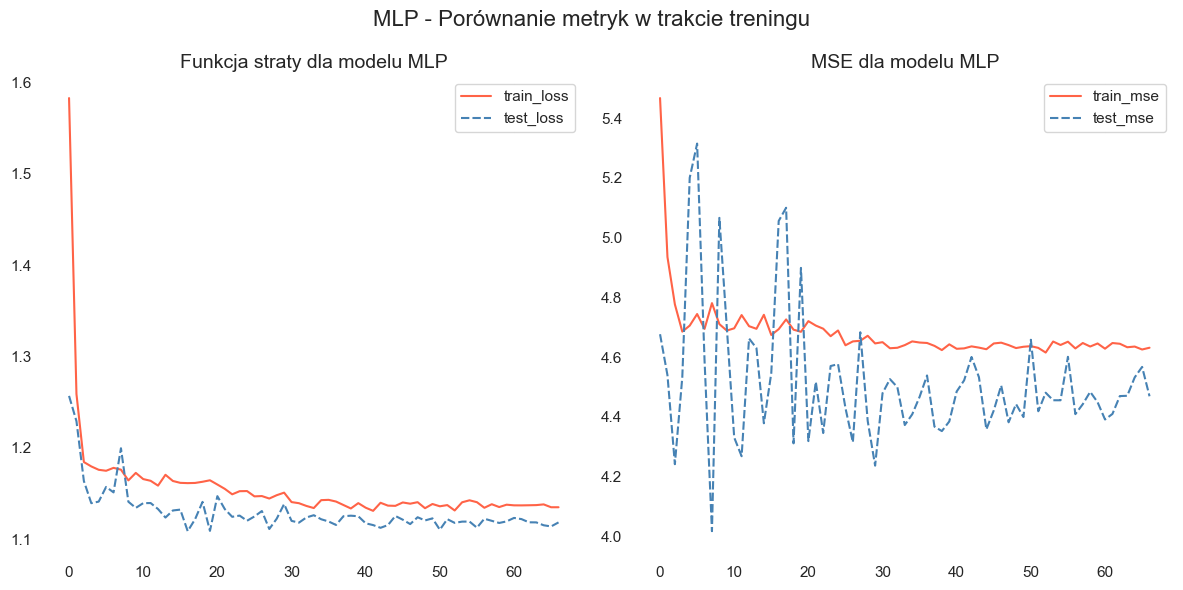

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

sns.lineplot(data=results_frame[["train_loss", "test_loss"]],
             palette=["tomato", "steelblue"],
             ax=ax[0])
ax[0].set_title("Funkcja straty dla modelu MLP", fontsize=14)

sns.lineplot(data=results_frame[["train_mse", "test_mse"]],
             palette=["tomato", "steelblue"],
             ax=ax[1])
ax[1].set_title("MSE dla modelu MLP", fontsize=14)

fig.suptitle("MLP - Porównanie metryk w trakcie treningu", fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
mlp.load_state_dict(best_model)
mlp.eval()

MLP(
  (block_stack): Sequential(
    (0): Sequential(
      (0): Linear(in_features=119, out_features=64, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.2, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=64, out_features=16, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=16, out_features=1, bias=True)
    )
  )
)

In [27]:
test_results = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[0:3]

y_pred = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[4]

In [28]:
y_test = data_splits["y_test"]

In [29]:
y_pred.shape, y_test.shape

(torch.Size([22343, 1]), (22343,))

In [30]:
preds = pd.DataFrame({
    "name" : data.loc[y_test.index, "name"],
    "y_true": y_test.values,
    "y_pred": y_pred.numpy().flatten()
})

In [31]:
preds.y_pred.max(), preds.y_true.max()

(np.float32(10.756205), np.float64(24.0))

In [32]:
preds.y_pred.min(), preds.y_true.min()

(np.float32(-0.105400145), np.float64(-3.0))

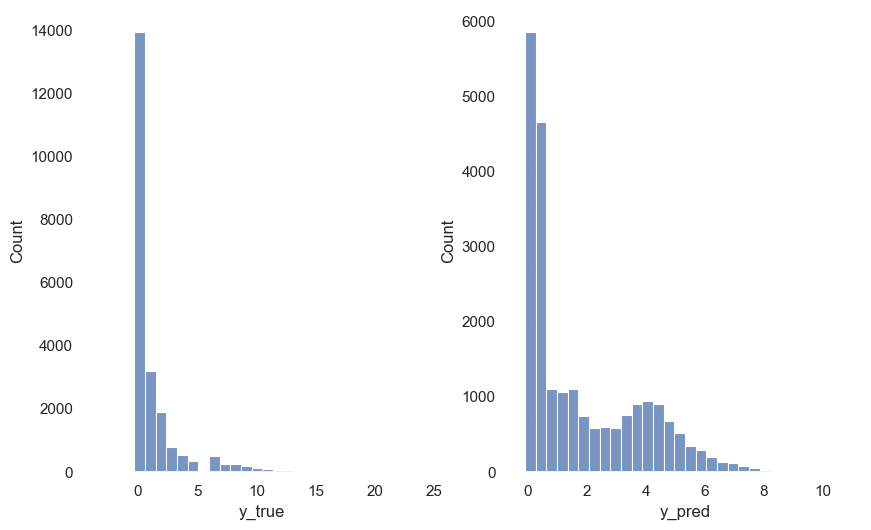

In [33]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 6))
for i, col in enumerate(["y_true", "y_pred"]):
    sns.histplot(data=preds[col], ax=ax[i], bins=30)

In [34]:
preds.head()

,name,y_true,y_pred
229,James Milner,1.0,1.388784
230,James Milner,0.0,1.420613
231,James Milner,6.0,0.848032
232,James Milner,1.0,2.638425
233,James Milner,1.0,3.937988


In [35]:
players = data.loc[y_test.index, ["name"]].sample(8, random_state=20021)
players

,name
101596,Miodrag Pivaš
61647,Jorge Cuenca Barreno
61099,Pau Torres
53485,Boubacar Kamara
22591,Bruno Borges Fernandes
76647,Senne Lammens
85563,Isaac Schmidt
68764,Ki-Jana Hoever


In [36]:
players = players.name

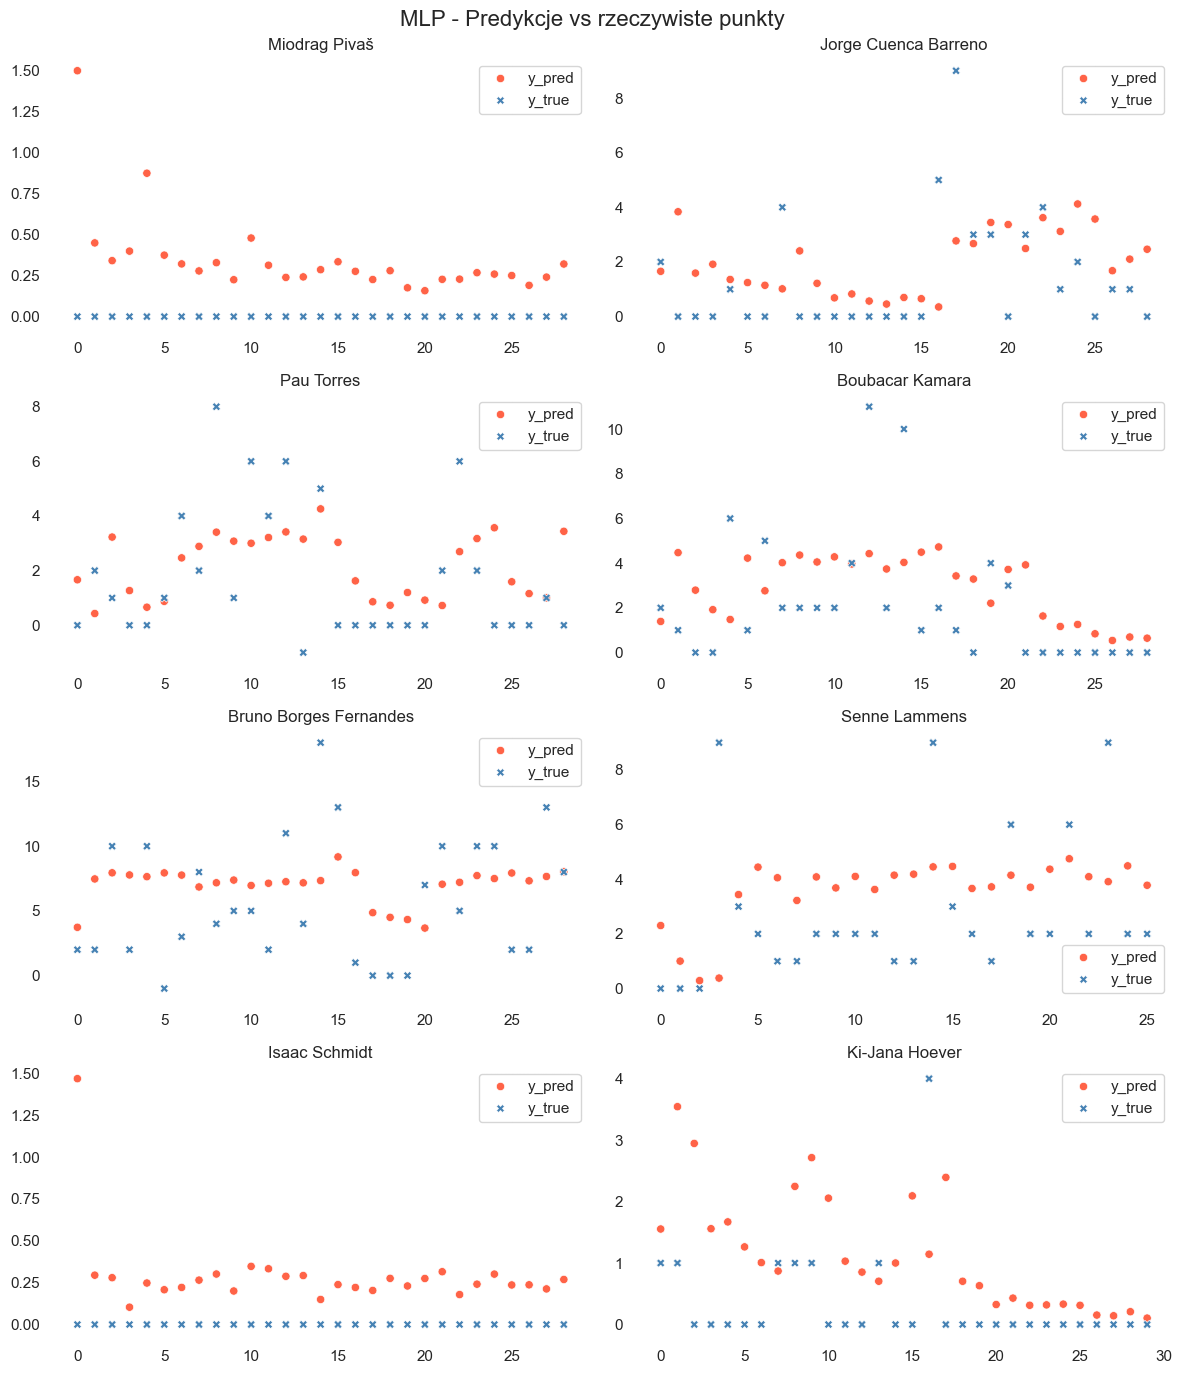

In [37]:
fig, ax = plt.subplots(nrows=4, ncols=len(players) // 4, figsize=(12, 14))
for i, player in enumerate(players):
    sns.scatterplot(data=preds.loc[preds.name==player, ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(player)
plt.suptitle("MLP - Predykcje vs rzeczywiste punkty", fontsize=16)
plt.tight_layout();


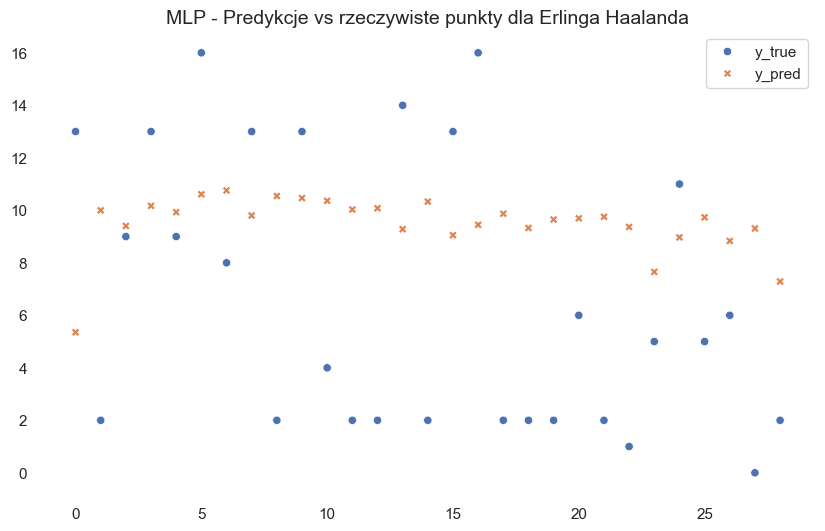

In [38]:
plt.figure(figsize=(10, 6))
plt.title("MLP - Predykcje vs rzeczywiste punkty dla Erlinga Haalanda", fontsize=14)
sns.scatterplot(data=preds.loc[preds.name=="Erling Haaland", ["y_true", "y_pred"]].reset_index(drop=True));

